# LEARNING PURPOSES ONLY

In [18]:
from pathlib import Path

import pymupdf4llm

data_dir = Path() / "data"
scenarios = [
    "monsters-inc-2001.pdf",
    "the-incredibles-2004.pdf",
    "ratatouille-2007.pdf",
    "wall-e-2008.pdf",
    "up-2009.pdf",
    "toy-story-3-2010.pdf",
    "monsters-university-2013.pdf",
    "the-good-dinosaur-2015.pdf",
    "inside-out-2015.pdf",
    "coco-2017.pdf",
    "toy-story-4-2019.pdf",
    "soul-2020.pdf",
    "soul-2020.pdf",
    "elemental-2023.pdf",
]

output_file = "pixar.txt"

with open(data_dir / output_file, "w") as pixar_file:
    for scenario in scenarios:
        content = pymupdf4llm.to_text(data_dir / scenario)
        assert isinstance(content, str), "Content is not `str`"
        pixar_file.write(content)


=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=0/1.


/home/ojke/ML-Learning/.venv/lib/python3.12/site-packages/pymupdf4llm/ocr/compute_ocr_features.py:236: RuntimeWarning: Mean of empty slice
  fft_ratio = magnitude[magnitude > magnitude.mean()].mean() / (
/home/ojke/ML-Learning/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=0/1.

=== Document parser messages ===
Using Tesseract for OCR processing.

=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=0/1.

=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=0/1.

=== Document parser messages ===
Using Tesseract for OCR processing.

=== Document parser messages ===
Using Tesseract for OCR processing.

=== Document parser messages ===
Using Tesseract for OCR processing.

=== Document parser messages ===
Using Tesseract for OCR processing.

=== Document parser messages ===
Using Tesseract for OCR processing.

=== Document parser messages ===
Using Tesseract for OCR processing.

=== Document parser messages ===
Using Tesseract for OCR processing.

=== Document parser messages ===
Using Tesseract for OCR processing.

=== Document parser messages ===
Using Tesseract for OCR processing.


In [ ]:
data_dir = Path() / "data"
output_file = "pixar.txt"
with open(data_dir / output_file, "r") as pixar_file:
    print(len(pixar_file.readlines()))

117763


In [22]:
from tokenizer import TokenizerBPE

vocab_size = 1024
tokenizer = TokenizerBPE(
    name=f"{vocab_size}",
    vocab_size=vocab_size,
    input_file_name=str(data_dir / output_file),
)

I0000 00:00:1786911874.748086  251702 sentencepiece_trainer.cc:105] Starts training with : 
trainer_spec {
  input: data/pixar.txt
  input_format: text
  model_prefix: 1024
  model_type: BPE
  vocab_size: 1024
  self_test_sample_size: 0
  character_coverage: 0.99995
  input_sentence_size: 200000000
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 10228
  num_threads: 12
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 1
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 1
  required_chars: 
  byte_fallback: 1
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: 3
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  en

In [12]:
from pathlib import Path

from numpy import median, percentile

data_dir = Path() / "data"
output_file = "pixar.txt"

def line_stats(lines):
    return {
        "min: ": min(lines),
        "p25: ": percentile(lines, 25),
        "median: ": median(lines),
        "p75: ": percentile(lines, 75),
        "p90: ": percentile(lines, 90),
        "max: ": max(lines),
    }

with open(data_dir / output_file, "r") as pixar_file:
    lines = [len(line) for line in pixar_file]
    print(line_stats(lines))

{'min: ': 1, 'p25: ': np.float64(1.0), 'median: ': np.float64(1.0), 'p75: ': np.float64(24.0), 'p90: ': np.float64(49.0), 'max: ': 852}


(array([1.15748e+05, 1.59900e+03, 3.21000e+02, 7.10000e+01, 1.60000e+01,
        3.00000e+00, 2.00000e+00, 0.00000e+00, 2.00000e+00, 1.00000e+00]),
 array([  1. ,  86.1, 171.2, 256.3, 341.4, 426.5, 511.6, 596.7, 681.8,
        766.9, 852. ]),
 <BarContainer object of 10 artists>)

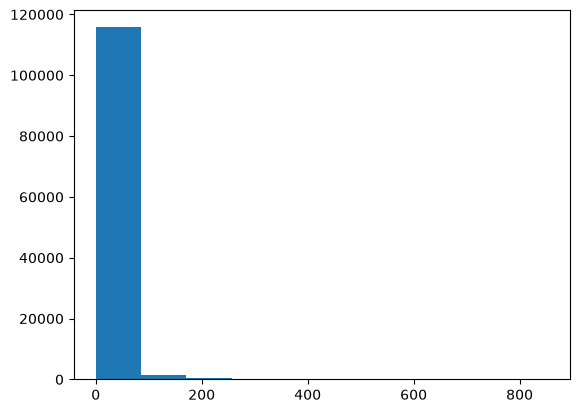

In [13]:
import matplotlib.pyplot as plt

plt.hist(lines)

In [14]:
from numpy import argmax


argmax(lines)

np.int64(8221)